# Transplant Analysis
- Dependent: Protein creatinine ratio, Albumin excretion 24h, Protein excretion 24h, Proteinuria_spot (qualitative present/absent), Proteinuria_24h (qualitative present/absent), Creatinine, Cystatin_C, eGFR_sCr, eGFR_Cystatin, CKD (qualitative, present/absent, which means GFR less than 60 based on Cystatin C)

In [5]:
import math
import subprocess
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn is available even in a fresh environment
try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

try:
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "plotly"])
    import plotly.express as px
    import plotly.graph_objects as go
    import plotly.io as pio

data_all = pd.read_csv('renal_all.csv')
data_notransplant = pd.read_csv('renal_notransplant.csv')
data_transplant = pd.read_csv('renal_transplant.csv')

data_all.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 35.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]


,DOS,VID,Sex,MMAtype0123,ID,Age,Sex_M_F,Transplant,TransplantType,Protein_Creatinine_Ratio,...,Microalbuminuria,Proteinuria_24h,Creatinine,Cystatin_C,eGFR_SCr,eGFR_CystatinC,CKD,PTH_pg_ml,Two_Truncating,CKD_StageCys
0,6/16/2011,VID.10286,0,0,1,5.750000,M,0,,,...,0,0,0.79,1.28,54.160506,56.1753128707481,1,,0,3
1,6/19/2014,VID.10286,0,0,1,8.758333,M,0,,.296,...,1,0,2.38,2.01,21.552353,36.9047656802983,1,115.8,0,3
2,8/20/2007,VID.10094,1,1,2,24.516667,F,0,,.158,...,1,1,0.93,,87.737906,,,,0,
3,8/23/2011,VID.10094,1,1,2,28.525000,F,0,,.162,...,,,0.97,.94,81.360607,89.25,0,,0,2
4,6/12/2017,VID.10149,1,1,3,11.813889,F,0,,,...,0,0,0.69,1.02,87.986957,69.3986818745387,0,44.4,0,2


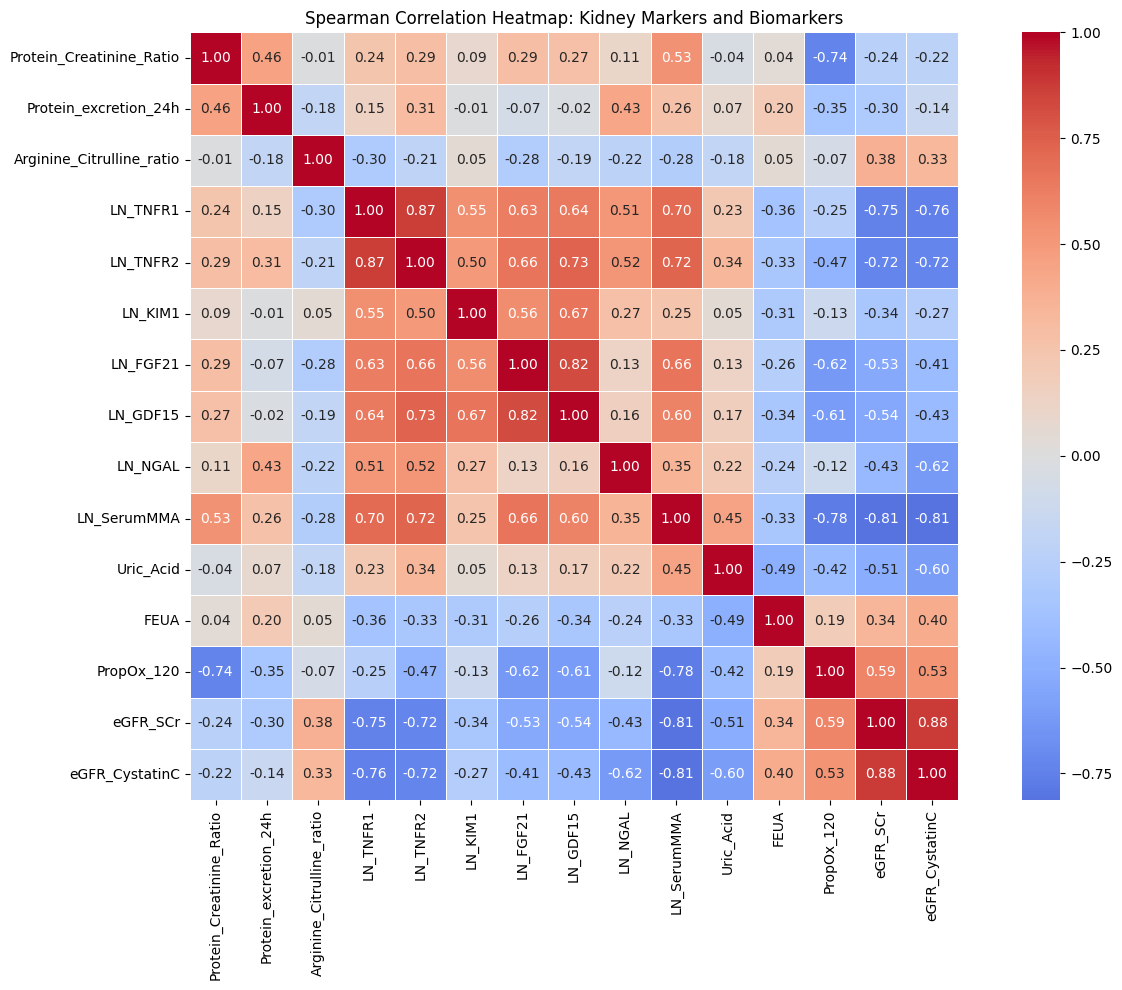

PropOx_120                   0.697917
Protein_excretion_24h        0.572917
LN_GDF15                     0.385417
Protein_Creatinine_Ratio     0.375000
LN_SerumMMA                  0.302083
LN_NGAL                      0.239583
LN_FGF21                     0.229167
FEUA                         0.229167
LN_TNFR1                     0.208333
LN_TNFR2                     0.187500
eGFR_CystatinC               0.166667
LN_KIM1                      0.156250
Uric_Acid                    0.114583
Arginine_Citrulline_ratio    0.052083
eGFR_SCr                     0.000000
LN_RBP4                      0.000000
LN_TGFb1                     0.000000
dtype: float64

In [6]:
# Heatmap for selected clinical + biomarker variables
heatmap_vars = [
    'Protein_Creatinine_Ratio',
    'Protein_excretion_24h',
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_120',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

# Optional sparse biomarkers are intentionally excluded from the default plot:
# LN_RBP4, LN_TGFb1

heatmap_df = data_all.copy()
for col in heatmap_vars:
    heatmap_df[col] = pd.to_numeric(heatmap_df[col], errors='coerce')

corr_matrix = heatmap_df[heatmap_vars].corr(method='spearman')

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title('Spearman Correlation Heatmap: Kidney Markers and Biomarkers')
plt.tight_layout()
plt.show()

# Quick completeness check for sparse features
missing_summary = heatmap_df[heatmap_vars + ['LN_RBP4', 'LN_TGFb1']].isna().mean().sort_values(ascending=False)
missing_summary

Kept targets for multi-output modeling: ['Protein_excretion_24h', 'Albumin_excretion_24h', 'Protein_Creatinine_Ratio', 'Cystatin_C', 'eGFR_CystatinC', 'Creatinine', 'eGFR_SCr']
Rows used for model: 96
Mean CV R2: -8.658 +/- 16.370
Mean CV RMSE (macro): 71.733
Mean CV MAE (macro): 21.965


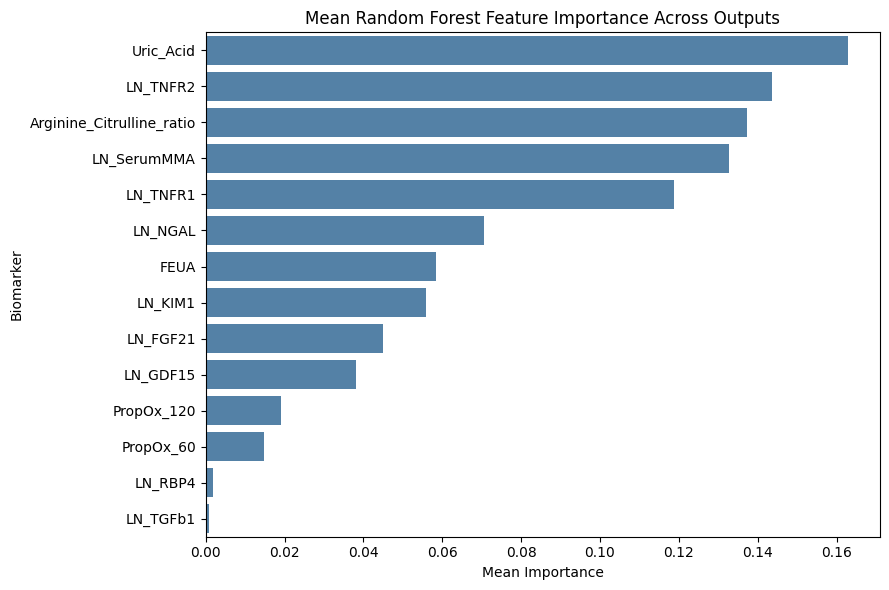

,feature,mean_importance
10,Uric_Acid,0.162884
2,LN_TNFR2,0.143560
0,Arginine_Citrulline_ratio,0.137404
9,LN_SerumMMA,0.132763
1,LN_TNFR1,0.118703
6,LN_NGAL,0.070498
11,FEUA,0.058384
3,LN_KIM1,0.056008
4,LN_FGF21,0.044950
5,LN_GDF15,0.038086


In [7]:
# Multi-output modeling: predict dependent variables from selected biomarkers
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_validate
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error

# Dependent variables from notebook description (using dataset column names)
dependent_vars = [
    'Protein_Creatinine_Ratio',
    'Albumin_excretion_24h',
    'Protein_excretion_24h',
    'Creatinine',
    'Cystatin_C',
    'eGFR_SCr',
    'eGFR_CystatinC',
]

# Independent biomarkers requested
independent_vars = [
    'Arginine_Citrulline_ratio',
    'LN_TNFR1',
    'LN_TNFR2',
    'LN_KIM1',
    'LN_FGF21',
    'LN_GDF15',
    'LN_NGAL',
    'LN_RBP4',
    'LN_TGFb1',
    'LN_SerumMMA',
    'Uric_Acid',
    'FEUA',
    'PropOx_60',
    'PropOx_120',
]

model_df = data_all[independent_vars + dependent_vars].copy()

# Coerce numeric
for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors='coerce')

# Drop targets that are mostly missing to keep a stable multi-output target matrix
target_missing = model_df[dependent_vars].isna().mean().sort_values(ascending=False)
kept_targets = target_missing[target_missing <= 0.60].index.tolist()

# Keep rows with at least one target present, then impute Y so multi-output model can run
model_df = model_df.loc[model_df[kept_targets].notna().any(axis=1)].copy()
X = model_df[independent_vars]
Y = model_df[kept_targets]

x_preprocess = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), independent_vars),
    ],
    remainder='drop'
)

y_imputer = SimpleImputer(strategy='median')
Y_imputed = pd.DataFrame(
    y_imputer.fit_transform(Y),
    columns=kept_targets,
    index=Y.index,
)

rf = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
    )
)

pipeline = Pipeline([
    ('x_preprocess', x_preprocess),
    ('rf_multi', rf),
])

# Evaluation: multi-output R2 + error-based metrics
def rmse_macro(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred, multioutput='uniform_average'))

def mae_macro(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred, multioutput='uniform_average')

scoring = {
    'r2': 'r2',
    'rmse_macro': make_scorer(rmse_macro, greater_is_better=False),
    'mae_macro': make_scorer(mae_macro, greater_is_better=False),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    pipeline,
    X,
    Y_imputed,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
)

print('Kept targets for multi-output modeling:', kept_targets)
print('Rows used for model:', len(X))
print(f"Mean CV R2: {cv_results['test_r2'].mean():.3f} +/- {cv_results['test_r2'].std():.3f}")
print(f"Mean CV RMSE (macro): {-cv_results['test_rmse_macro'].mean():.3f}")
print(f"Mean CV MAE (macro): {-cv_results['test_mae_macro'].mean():.3f}")

# Fit final model on all available rows
pipeline.fit(X, Y_imputed)

# Aggregate feature importance across all output models
feature_names = independent_vars
all_importances = np.array([
    est.feature_importances_ for est in pipeline.named_steps['rf_multi'].estimators_
])
mean_importance = all_importances.mean(axis=0)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_importance': mean_importance,
}).sort_values('mean_importance', ascending=False)

plt.figure(figsize=(9, 6))
sns.barplot(data=importance_df, x='mean_importance', y='feature', color='steelblue')
plt.title('Mean Random Forest Feature Importance Across Outputs')
plt.xlabel('Mean Importance')
plt.ylabel('Biomarker')
plt.tight_layout()
plt.show()

importance_df